In [58]:
import openseespywin as ops
import opsvis as opsv 
import numpy as np
import ipywidgets as widgets
import os
import matplotlib.pyplot as plt
import math
import opstool as opst
#import eurocodepy as ecpy
import time as tt 
# import openseespy.postprocessing.Get_Rendering as opsplt

In [59]:
import sys
sys.path.append('Data')
import functions.solver_function as SF
import importlib
importlib.reload(SF)
from functions.solver_function import *  

In [60]:
opst.add_ops_hints_file()

OPSTOOL :: opensees.pyi file has been created to C:\Users\Michael 
Ocampo\Documents\mini\envs\blue_env\Lib\site-packages\openseespywin\opensees.pyi!

In [61]:
convert_tcl = 'no'
if(convert_tcl=="yes"):
    opst.pre.tcl2py(input_file='create.tcl',
                output_file='create',
                prefix="ops")

In [62]:
length_unit = "m"  # base unit
force_unit = "KN"  # base unit

UNIT = opst.pre.UnitSystem(length=length_unit, force=force_unit)

print("Length:", UNIT.mm, UNIT.mm2, UNIT.cm, UNIT.m,)
print("Force", UNIT.N, UNIT.kN, )
print("Stress", UNIT.MPa, UNIT.kPa, UNIT.Pa, )
print("Mass", UNIT.g, UNIT.kg, UNIT.ton)
print(UNIT)

Length: 0.001 1e-06 0.01 1
Force 0.001 1
Stress 1000.0 1.0 0.001
Mass 1e-06 0.001 1.0
<UnitSystem: length='m', force='kn', time='sec' (126537654889)>


In [63]:
# User-defined variables
massDen = 2.000
massProportionalDamping = 0.0
stiffnessProportionalDamping = 0.001
fangle = 31.4
ptangle = 26.5
E1 = 90000.0
poisson1 = 0.40
G = E1 / (2 * (1 + poisson1))
B = E1 / (3 * (1 - 2 * poisson1))
press = 0.0
loadIncr = 1.0
period = 2.0
deltaT = 0.01
numSteps = 2000
gamma = 0.5
unitWeightX = 0.0
unitWeightY = -9.81 * massDen

ops.wipe()
# ModelBuilder
ops.model('basic', '-ndm', 2, '-ndf', 2)

# Materials
ops.nDMaterial('PressureDependMultiYield', 2, 2, massDen, G, B, fangle, 0.1, 80, 0.5,
               ptangle, 0.17, 0.4, 10, 10, 0.015, 1.0)
ops.nDMaterial('FluidSolidPorous', 1, 2, 2, 2.2e6)

# Nodes
ops.node(1, 0.0, 0.0)
ops.node(2, 1.0, 0.0)
ops.node(3, 1.0, 1.0)
ops.node(4, 0.0, 1.0)

# Element
ops.element('quad', 1, 1, 2, 3, 4, 1.0, 'PlaneStrain', 2, press, 0.0, unitWeightX, unitWeightY)

ops.updateMaterialStage('-material', 2, '-stage', 0)

# Boundary conditions
ops.fix(1, 1, 1)
ops.fix(2, 1, 1)
ops.equalDOF(3, 4, 1, 2)

# Gravity application
ops.system('ProfileSPD')
ops.test('NormDispIncr', 1e-12, 25, 0)
ops.constraints('Transformation')
ops.integrator('LoadControl', 1, 1, 1, 1)
ops.algorithm('Newton')
ops.numberer('RCM')
ops.analysis('Static')
ops.analyze(2)

# Switch to elastic pressure dependent stage
ops.updateMaterialStage('-material', 2, '-stage', 2)
ops.analyze(1)

0

In [64]:
ops.printModel()

Current Domain Information
	Current Time: 3
	Committed Time: 3
NODE DATA: NumNodes: 4

numComponents: 4

 Node: 1
	Coordinates  : 0 0 
	Disps: 0 0 
	 unbalanced Load: 0 0 
	ID : -1 -1 


 Node: 2
	Coordinates  : 1 0 
	Disps: 0 0 
	 unbalanced Load: 0 0 
	ID : -1 -1 


 Node: 3
	Coordinates  : 1 1 
	Disps: 0 -5.08667e-05 
	 unbalanced Load: 0 0 
	ID : 0 1 


 Node: 4
	Coordinates  : 0 1 
	Disps: 0 -5.08667e-05 
	 unbalanced Load: 0 0 
	ID : 0 1 

ELEMENT DATA: NumEle: 1

numComponents: 1

FourNodeQuad, element id:  1
	Connected external nodes:  1 2 3 4 
	thickness:  1
	surface pressure:  0
	mass density:  0
	body forces:  0 -19.62
PressureDependMultiYield - loadSatge: 2
	Stress (xx yy xy)
		Gauss point 1: -6.54 -9.81 0 
		Gauss point 2: -6.54 -9.81 0 
		Gauss point 3: -6.54 -9.81 0 
		Gauss point 4: -6.54 -9.81 0 

SP_Constraints: numConstraints: 4

numComponents: 4
SP_Constraint: 0	 Node: 1 DOF: 1 ref value: 0 current value: 0 initial value: 0
SP_Constraint: 1	 Node: 1 DOF: 2 ref value

In [65]:
opst.vis.plotly.plot_model(show_node_numbering=True, show_ele_numbering=False, show_nodal_loads = True)

In [66]:
# Loading sequence
ops.setTime(0.0)
ops.wipeAnalysis()
ops.timeSeries('Linear', 1)
ops.pattern('Plain', 1, 1)
ops.load(3, loadIncr, 0.0)

ops.constraints('Transformation')
ops.test('NormDispIncr', 1e-12, 25, 0)
ops.algorithm('Newton')
ops.numberer('RCM')
ops.system('ProfileSPD')
ops.rayleigh(massProportionalDamping, 0.0, stiffnessProportionalDamping, 0.0)
ops.integrator('Newmark', gamma, (gamma + 0.5)**2 / 4)
ops.analysis('VariableTransient')

# Recorders
ops.recorder('Node', '-file', 'jdisp.out', '-time', '-node', 1, 2, 3, 4, '-dof', 1, 2, '-dT', 0.01, 'disp')
ops.recorder('Node', '-file', 'jacce.out', '-time', '-node', 1, 2, 3, 4, '-dof', 1, 2, '-dT', 0.01, 'accel')
ops.recorder('Element', '-ele', 1, '-time', '-file', 'jstress1.out', '-dT', 0.01, 'material', 1, 'stress')
ops.recorder('Element', '-ele', 1, '-time', '-file', 'jstrain1.out', '-dT', 0.01, 'material', 1, 'strain')
ops.recorder('Element', '-ele', 1, '-time', '-file', 'jstress3.out', '-dT', 0.01, 'material', 3, 'stress')
ops.recorder('Element', '-ele', 1, '-time', '-file', 'jstrain3.out', '-dT', 0.01, 'material', 3, 'strain')

# Analysis
startT = tt.time()
ops.analyze(numSteps, deltaT, deltaT/100, deltaT, 10)
endT = tt.time()
print(f"Execution time: {endT - startT} seconds.")

ops.wipe()

Execution time: 0.07947492599487305 seconds.


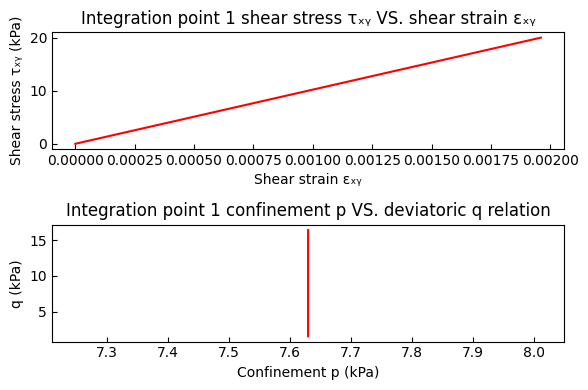

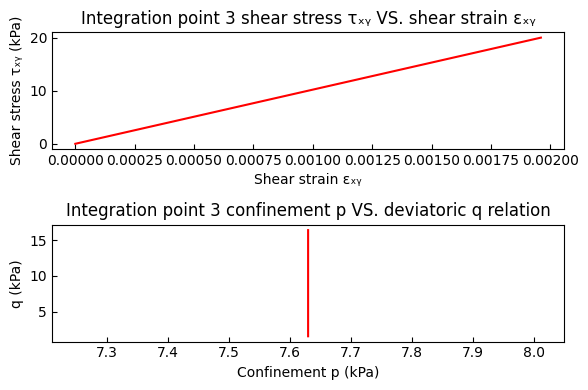

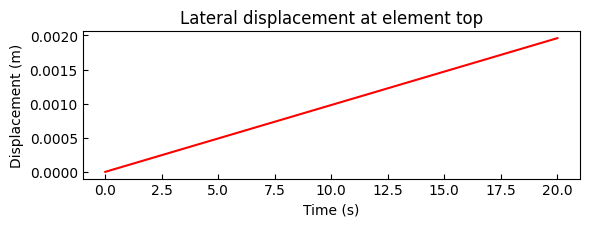

In [67]:
import numpy as np
import matplotlib.pyplot as plt

# Load data
a1 = np.loadtxt('jacce.out')
d1 = np.loadtxt('jdisp.out')
s1 = np.loadtxt('jstress1.out')
e1 = np.loadtxt('jstrain1.out')
s5 = np.loadtxt('jstress3.out')
e5 = np.loadtxt('jstrain3.out')

# Approximate MATLAB figure paperposition
figsize = (6, 4)

def compute_p_q(stress):
    """Compute confinement p (po) and deviatoric stress q (qo)."""
    po = np.mean(stress[:, 1:4], axis=1)  # cols 2,3,4 in MATLAB
    qo = []
    for i in range(len(stress)):
        q = ((stress[i,1] - stress[i,2])**2 +
             (stress[i,2] - stress[i,3])**2 +
             (stress[i,1] - stress[i,3])**2 +
             6.0 * stress[i,4]**2)
        q = np.sign(stress[i,4]) * (1/3.0) * np.sqrt(q)
        qo.append(q)
    return po, np.array(qo)

# --- Integration Point 1 ---
po1, qo1 = compute_p_q(s1)

plt.figure(1, figsize=figsize)
plt.clf()
plt.subplot(2,1,1)
plt.plot(e1[:,3], s1[:,4], 'r')  # MATLAB col 4 & 5 → Python col 3 & 4
plt.title('Integration point 1 shear stress τₓᵧ VS. shear strain εₓᵧ')
plt.xlabel('Shear strain εₓᵧ')
plt.ylabel('Shear stress τₓᵧ (kPa)')

plt.subplot(2,1,2)
plt.plot(-po1, qo1, 'r')
plt.title('Integration point 1 confinement p VS. deviatoric q relation')
plt.xlabel('Confinement p (kPa)')
plt.ylabel('q (kPa)')

plt.tight_layout()
plt.savefig('SS_PQ1.jpg')
plt.show()

# --- Integration Point 3 ---
po3, qo3 = compute_p_q(s5)

plt.figure(4, figsize=figsize)
plt.clf()
plt.subplot(2,1,1)
plt.plot(e5[:,3], s5[:,4], 'r')
plt.title('Integration point 3 shear stress τₓᵧ VS. shear strain εₓᵧ')
plt.xlabel('Shear strain εₓᵧ')
plt.ylabel('Shear stress τₓᵧ (kPa)')

plt.subplot(2,1,2)
plt.plot(-po3, qo3, 'r')
plt.title('Integration point 3 confinement p VS. deviatoric q relation')
plt.xlabel('Confinement p (kPa)')
plt.ylabel('q (kPa)')

plt.tight_layout()
plt.savefig('SS_PQ5.jpg')
plt.show()

# --- Displacement ---
plt.figure(2, figsize=figsize)
plt.clf()
plt.subplot(2,1,1)
plt.plot(d1[:,0], d1[:,5], 'r')  # MATLAB col 6 → Python col 5
plt.title('Lateral displacement at element top')
plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')

plt.tight_layout()
plt.savefig('D.jpg')
plt.show()
